# Backpropagation: Binary Classification with a Multi-Layer Perceptron
This notebook implements a multi-layer perceptron from scratch using NumPy
and trains it with backpropagation. The network classifies points into two
classes based on a single feature, using an input layer, one hidden layer,
and a single output node.

# Section 1: Imports

In [8]:
import numpy as np

In [9]:
import matplotlib.pyplot as plt

In [10]:
import seaborn as sns

In [11]:
# Set a consistent visual style for all plots
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# Section 2: Data Generation & Exploration

In [12]:
def generate_data(n_samples=100, low=-2.0, high=2.0, seed=0):
    """
    Generate a 1-D binary classification dataset.

    Points are sampled uniformly on [low, high] and labelled 1 if the
    feature is non-negative, else 0. The classes are therefore separable
    at x = 0.

    Parameters
    ----------
    n_samples : int
        Number of points to generate.
    low, high : float
        Range of the feature values.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    X : np.ndarray, shape (n_samples, 1)
    y : np.ndarray, shape (n_samples, 1)
    """
    np.random.seed(seed)
    X = np.random.uniform(low, high, size=(n_samples, 1))
    y = (X >= 0).astype(int)
    return X, y

In [13]:
X, y = generate_data()

In [14]:
def plot_data(X, y):
    """Scatter the two classes along the feature axis."""
    plt.figure(figsize=(6, 4))
    plt.scatter(X[y == 0], np.zeros_like(X[y == 0]),
                color="steelblue", label="Class 0")
    plt.scatter(X[y == 1], np.zeros_like(X[y == 1]),
                color="firebrick", label="Class 1")
    plt.title("Input Data", fontweight="bold")
    plt.xlabel("Feature")
    plt.yticks([])
    plt.legend()
    plt.tight_layout()
    plt.savefig("input_data.png", bbox_inches="tight")
    plt.show()

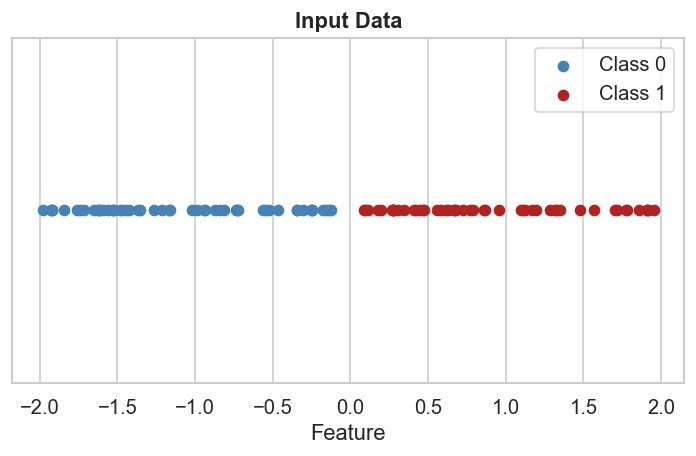

In [15]:
plot_data(X, y)

## Interpretation:
- The two classes are cleanly separated at the feature value 0.
- This is a linearly separable problem, so a small network should reach
  high accuracy.
- A non-linear hidden activation (sigmoid) is still used so the network
  can learn the boundary through backpropagation.

# Section 3: Network Setup

The network uses a single input feature, one hidden layer, and one output
node. Three settings must be chosen before training:

- **Size of the network** – the hidden layer can be any size; more nodes
  add capacity but also cost and overfitting risk. The output is one node
  for binary classification.
- **Number of iterations** – how many times the weights are updated.
- **Learning rate** – the step size of each update. Too small trains
  slowly; too large can make training unstable.

In [16]:
def sigmoid(x):
    """Sigmoid activation, squashing values into (0, 1)."""
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of the sigmoid with respect to its input."""
    return sigmoid(x) * (1 - sigmoid(x))

In [17]:
def get_activation(name):
    """
    Return the (activation, derivative) pair for a hidden layer.

    Parameters
    ----------
    name : str
        One of 'sigmoid', 'tanh', or 'relu'.

    Returns
    -------
    tuple of callables : (activation, derivative)
    """
    if name == "sigmoid":
        return sigmoid, sigmoid_derivative
    if name == "tanh":
        return np.tanh, (lambda x: 1 - np.tanh(x) ** 2)
    if name == "relu":
        return (lambda x: np.maximum(0, x)), (lambda x: (x > 0).astype(float))
    raise ValueError(f"Unknown activation: {name}")

In [18]:
def initialise_parameters(input_size, hidden_size, output_size=1, seed=1):
    """
    Initialise weight matrices with small random values.

    Parameters
    ----------
    input_size, hidden_size, output_size : int
        Number of nodes in each layer.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    W1 : np.ndarray, shape (input_size, hidden_size)
    W2 : np.ndarray, shape (hidden_size, output_size)
    """
    np.random.seed(seed)
    W1 = np.random.randn(input_size, hidden_size)   # Input -> hidden
    W2 = np.random.randn(hidden_size, output_size)  # Hidden -> output
    return W1, W2

In [19]:
# Network sizes and training hyperparameters
input_size = 1     # One input feature
hidden_size = 4    # Four hidden nodes
output_size = 1    # One output node for binary classification
num_iter = 10000
learning_rate = 0.5

# Section 4: Training

In [20]:
def compute_loss(y, y_pred, eps=1e-8):
    """Binary cross-entropy loss. eps avoids log(0)."""
    return -np.mean(y * np.log(y_pred + eps)
                    + (1 - y) * np.log(1 - y_pred + eps))

In [21]:
def accuracy(y, y_pred):
    """Fraction of correct predictions at the 0.5 threshold."""
    return np.mean((y_pred >= 0.5).astype(int) == y)

In [22]:
def train(X, y, hidden_size=4, num_iter=10000, learning_rate=0.5,
          activation="sigmoid", seed=1, verbose=False):
    """
    Train a one-hidden-layer MLP with backpropagation.

    Forward pass: input -> hidden (chosen activation) -> output (sigmoid).
    Backward pass: gradients of the binary cross-entropy loss are
    propagated back and the weights updated by gradient descent.

    Parameters
    ----------
    X, y : np.ndarray
        Feature matrix and binary labels.
    hidden_size : int
        Number of hidden nodes.
    num_iter : int
        Number of training iterations.
    learning_rate : float
        Gradient descent step size.
    activation : str
        Hidden layer activation ('sigmoid', 'tanh', 'relu').
    seed : int
        Random seed for weight initialisation.
    verbose : bool
        If True, print the loss every 100 iterations.

    Returns
    -------
    W1, W2 : np.ndarray
        Trained weight matrices.
    losses : list of float
        Loss recorded at each iteration.
    y_pred : np.ndarray
        Final predicted probabilities.
    """
    act, act_deriv = get_activation(activation)
    W1, W2 = initialise_parameters(X.shape[1], hidden_size, 1, seed)
    losses = []

    for i in range(num_iter):
        # Forward pass
        Z1 = np.dot(X, W1)
        A1 = act(Z1)
        Z2 = np.dot(A1, W2)
        y_pred = sigmoid(Z2)  # Sigmoid output for a 0-1 probability

        # Loss
        loss = compute_loss(y, y_pred)
        losses.append(loss)

        # Backward pass
        dZ2 = (y_pred - y) / len(y)        # BCE + sigmoid output gradient
        dW2 = np.dot(A1.T, dZ2)            # Hidden -> output
        dA1 = np.dot(dZ2, W2.T)            # Error back to hidden layer
        dZ1 = dA1 * act_deriv(Z1)          # Hidden activation derivative
        dW1 = np.dot(X.T, dZ1)             # Input -> hidden

        # Update weights
        W2 -= learning_rate * dW2
        W1 -= learning_rate * dW1

        if verbose and i % 100 == 0:
            print(f"Iteration {i:>5}, Loss: {loss:.4f}")

    return W1, W2, losses, y_pred

In [23]:
W1, W2, losses, y_pred = train(
    X, y,
    hidden_size=hidden_size,
    num_iter=num_iter,
    learning_rate=learning_rate,
    verbose=True,
)

Iteration     0, Loss: 0.4730
Iteration   100, Loss: 0.0835
Iteration   200, Loss: 0.0507
Iteration   300, Loss: 0.0369
Iteration   400, Loss: 0.0291
Iteration   500, Loss: 0.0240
Iteration   600, Loss: 0.0205
Iteration   700, Loss: 0.0178
Iteration   800, Loss: 0.0158
Iteration   900, Loss: 0.0141
Iteration  1000, Loss: 0.0128
Iteration  1100, Loss: 0.0116
Iteration  1200, Loss: 0.0107
Iteration  1300, Loss: 0.0099
Iteration  1400, Loss: 0.0092
Iteration  1500, Loss: 0.0086
Iteration  1600, Loss: 0.0080
Iteration  1700, Loss: 0.0075
Iteration  1800, Loss: 0.0071
Iteration  1900, Loss: 0.0067
Iteration  2000, Loss: 0.0064
Iteration  2100, Loss: 0.0060
Iteration  2200, Loss: 0.0058
Iteration  2300, Loss: 0.0055
Iteration  2400, Loss: 0.0053
Iteration  2500, Loss: 0.0050
Iteration  2600, Loss: 0.0048
Iteration  2700, Loss: 0.0046
Iteration  2800, Loss: 0.0045
Iteration  2900, Loss: 0.0043
Iteration  3000, Loss: 0.0041
Iteration  3100, Loss: 0.0040
Iteration  3200, Loss: 0.0038
Iteration 

# Section 5: Evaluation

In [24]:
print("=" * 60)
print("  Training Result")
print("=" * 60)
print(f"  Final loss:        {losses[-1]:.4f}")
print(f"  Training accuracy: {accuracy(y, y_pred):.2%}")

  Training Result
  Final loss:        0.0011
  Training accuracy: 100.00%


In [25]:
def plot_predictions(X, y, y_pred):
    """Plot true classes against the network's predicted classes."""
    plt.figure(figsize=(6, 4))
    plt.scatter(X[y == 0], np.zeros_like(X[y == 0]),
                color="steelblue", label="Class 0")
    plt.scatter(X[y == 1], np.zeros_like(X[y == 1]),
                color="firebrick", label="Class 1")
    plt.scatter(X, (y_pred >= 0.5).astype(int),
                color="seagreen", marker="x", label="Predicted")
    plt.title("Predicted vs Actual", fontweight="bold")
    plt.xlabel("Feature")
    plt.ylabel("Class")
    plt.legend()
    plt.tight_layout()
    plt.savefig("predictions.png", bbox_inches="tight")
    plt.show()

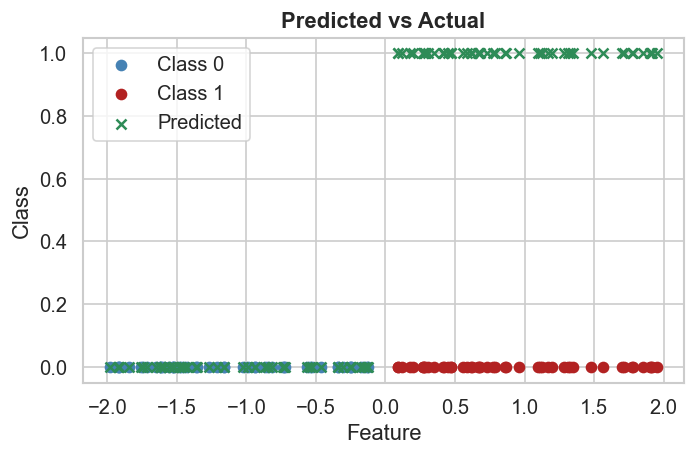

In [26]:
plot_predictions(X, y, y_pred)

## Interpretation:
- The predicted classes (green) sit at 0 for negative features and 1 for
  positive features, matching the true labels.
- The network has learned the boundary at x = 0 and reaches 100% training
  accuracy.

In [27]:
def plot_loss(losses):
    """Plot the binary cross-entropy loss over training."""
    plt.figure(figsize=(6, 4))
    plt.plot(losses, color="steelblue", linewidth=2)
    plt.title("Training Loss", fontweight="bold")
    plt.xlabel("Iteration")
    plt.ylabel("Binary cross-entropy loss")
    plt.tight_layout()
    plt.savefig("training_loss.png", bbox_inches="tight")
    plt.show()

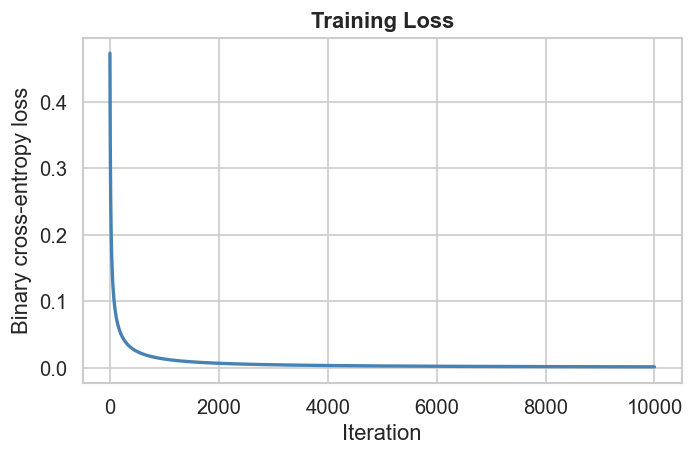

In [28]:
plot_loss(losses)

## Interpretation:
- The loss falls steeply in the first few hundred iterations, then keeps
  decreasing more slowly.
- The smooth, monotonic curve shows stable training at this learning rate.

# Section 6: Experiments

Below we vary the learning rate and iterations, the hidden layer size, and
the hidden activation function. Because the classes are separable at x = 0,
most settings reach 100% accuracy, so we compare them mainly on the final
loss and how quickly it converges.

In [29]:
def run_experiment(X, y, **kwargs):
    """Train once and return the final loss and accuracy."""
    _, _, losses, y_pred = train(X, y, **kwargs)
    return losses[-1], accuracy(y, y_pred)

In [30]:
# Vary learning rate and number of iterations
print(f"{'lr':>6} {'iters':>7} {'loss':>10} {'accuracy':>10}")
for lr in [0.01, 0.1, 0.5, 1.0]:
    for ni in [1000, 5000, 10000]:
        loss, acc = run_experiment(X, y, num_iter=ni, learning_rate=lr)
        print(f"{lr:>6} {ni:>7} {loss:>10.4f} {acc:>10.2%}")

    lr   iters       loss   accuracy
  0.01    1000     0.2165    100.00%
  0.01    5000     0.0840    100.00%
  0.01   10000     0.0509    100.00%
   0.1    1000     0.0509    100.00%
   0.1    5000     0.0128    100.00%
   0.1   10000     0.0064    100.00%
   0.5    1000     0.0128    100.00%
   0.5    5000     0.0023    100.00%
   0.5   10000     0.0011    100.00%
   1.0    1000     0.0064    100.00%
   1.0    5000     0.0011    100.00%
   1.0   10000     0.0005    100.00%


## Interpretation:
- Every combination reached 100% accuracy, so the difference shows up in
  the loss.
- A small rate (0.01) trained slowly, still around 0.05 after 10000
  iterations.
- Larger rates converged much faster: 0.5 reached about 0.001 by 10000
  iterations, and 1.0 was stable too on this simple problem.
- A learning rate of 0.5 with 10000 iterations is a good balance of speed
  and stability, so those values are used above.

In [31]:
# Vary the hidden layer size
print(f"{'hidden':>7} {'loss':>10} {'accuracy':>10}")
for h in [1, 2, 4, 8, 16]:
    loss, acc = run_experiment(X, y, hidden_size=h,
                               num_iter=10000, learning_rate=0.5)
    print(f"{h:>7} {loss:>10.4f} {acc:>10.2%}")

 hidden       loss   accuracy
      1     0.3630     49.00%
      2     0.0011    100.00%
      4     0.0011    100.00%
      8     0.0010    100.00%
     16     0.0010    100.00%


## Interpretation:
- A single hidden node failed to learn (about 50% accuracy): with no bias
  term, one neuron cannot reliably place the boundary.
- From two nodes upward the network reached 100% accuracy.
- Adding more nodes (8 or 16) barely changed the final loss.
- Four nodes are more than enough here; extra capacity mainly adds compute
  and overfitting risk without improving results.

In [32]:
# Vary the hidden activation function
print(f"{'activation':>10} {'loss':>10} {'accuracy':>10}")
for act in ["sigmoid", "tanh", "relu"]:
    loss, acc = run_experiment(X, y, activation=act,
                               num_iter=10000, learning_rate=0.5)
    print(f"{act:>10} {loss:>10.4f} {acc:>10.2%}")

activation       loss   accuracy
   sigmoid     0.0011    100.00%
      tanh     0.0002    100.00%
      relu     0.0005    100.00%


## Interpretation:
- tanh and ReLU (with sigmoid kept on the output for a 0-1 probability)
  also reached 100% accuracy.
- tanh gave the lowest final loss and ReLU was close, both slightly better
  than sigmoid at the same settings.
- Both avoid sigmoid's flat, near-zero-gradient regions, so they train a
  little faster here.
- Changing the hidden activation also requires swapping its derivative in
  the backward pass, which `get_activation` handles automatically.